# Completing the dwelling stock

I use the observed EPC records to generate missing dwelling attributes by LSOA and accommodation type, then assemble the completed stock.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


## 1 · Setup

In [1]:
# Run this notebook on the `mostly` kernel (conda env `mostly`), which already has
# mostlyai + torch. Uncomment only if you are running somewhere that doesn't.
try:
    import mostlyai.sdk  # noqa: F401
    print('mostlyai already available')
except ImportError:
    %pip install -q "mostlyai[local]"

mostlyai already available


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from mostlyai.sdk import MostlyAI

DATA = Path('data')
OUT  = Path('output'); OUT.mkdir(exist_ok=True)

FEATURES = ['accommodation_type', 'Heat system', 'wall_construction', 'wall_insulation',
            'glazing_type', 'roof_type', 'TENURE', 'age_band']
TRAIN_COLS = FEATURES + ['LSOA']
SEED_COLS  = ['LSOA', 'accommodation_type']

mostly = MostlyAI(local=True)
print('MOSTLY AI ready — local mode')

W0802 12:46:22.322000 46024 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Initializing Synthetic Data SDK 6.1.1 in LOCAL mode 🏠

Connected to ]8;id=5838200;http://127.0.0.1:8080\http://127.0.0.1:8080]8;;\ with 128 GB RAM, 32 CPUs, 0 GPUs available

MOSTLY AI ready — local mode


## 2 · Load the prepared data

`POSTCODE` and `UPRN` are excluded from training. `UPRN` is a unique identifier, not a statistical
feature — including it would let the model memorise rows. `POSTCODE` is high-cardinality and adds
nothing once `LSOA` is present (it also crashed the original run on Windows via
`TABULAR_CHARACTER` encoding).

In [3]:
train_full = pd.read_csv(DATA / 'epc_train.csv', dtype={'UPRN': str})
test_full  = pd.read_csv(DATA / 'epc_test.csv',  dtype={'UPRN': str})
gap_seed   = pd.read_csv(DATA / 'epc_gap_seed.csv')

census   = pd.read_csv(DATA / 'census_targets.csv', index_col='LSOA')
observed = pd.read_csv(DATA / 'observed_counts.csv', index_col='LSOA')

train = train_full[TRAIN_COLS].copy()      # what the generator sees
test  = test_full[TRAIN_COLS].copy()

print(f'train    : {len(train):,} rows | {train["LSOA"].nunique()} LSOAs | {train.shape[1]} cols')
print(f'test     : {len(test):,} rows  | {test["LSOA"].nunique()} LSOAs')
print(f'gap seed : {len(gap_seed):,} rows | {gap_seed["LSOA"].nunique()} LSOAs')
print(f'\ncolumns: {train.columns.tolist()}')
assert train['LSOA'].nunique() == 84, 'not all 84 LSOAs present in training'
train.head(3)

train    : 32,720 rows | 84 LSOAs | 9 cols
test     : 8,183 rows  | 84 LSOAs
gap seed : 16,493 rows | 83 LSOAs

columns: ['accommodation_type', 'Heat system', 'wall_construction', 'wall_insulation', 'glazing_type', 'roof_type', 'TENURE', 'age_band', 'LSOA']


,accommodation_type,Heat system,wall_construction,wall_insulation,glazing_type,roof_type,TENURE,age_band,LSOA
0,Terraced,Gas boiler,Solid brick,Uninsulated,Double,Pitched insulated,unknown,C,E01030452
1,Terraced,Gas boiler,Cavity,Insulated,Double,Pitched insulated,rented (private),I,E01030468
2,Terraced,Gas boiler,Cavity,Uninsulated,Double,Pitched insulated,rented (private),E,E01030468


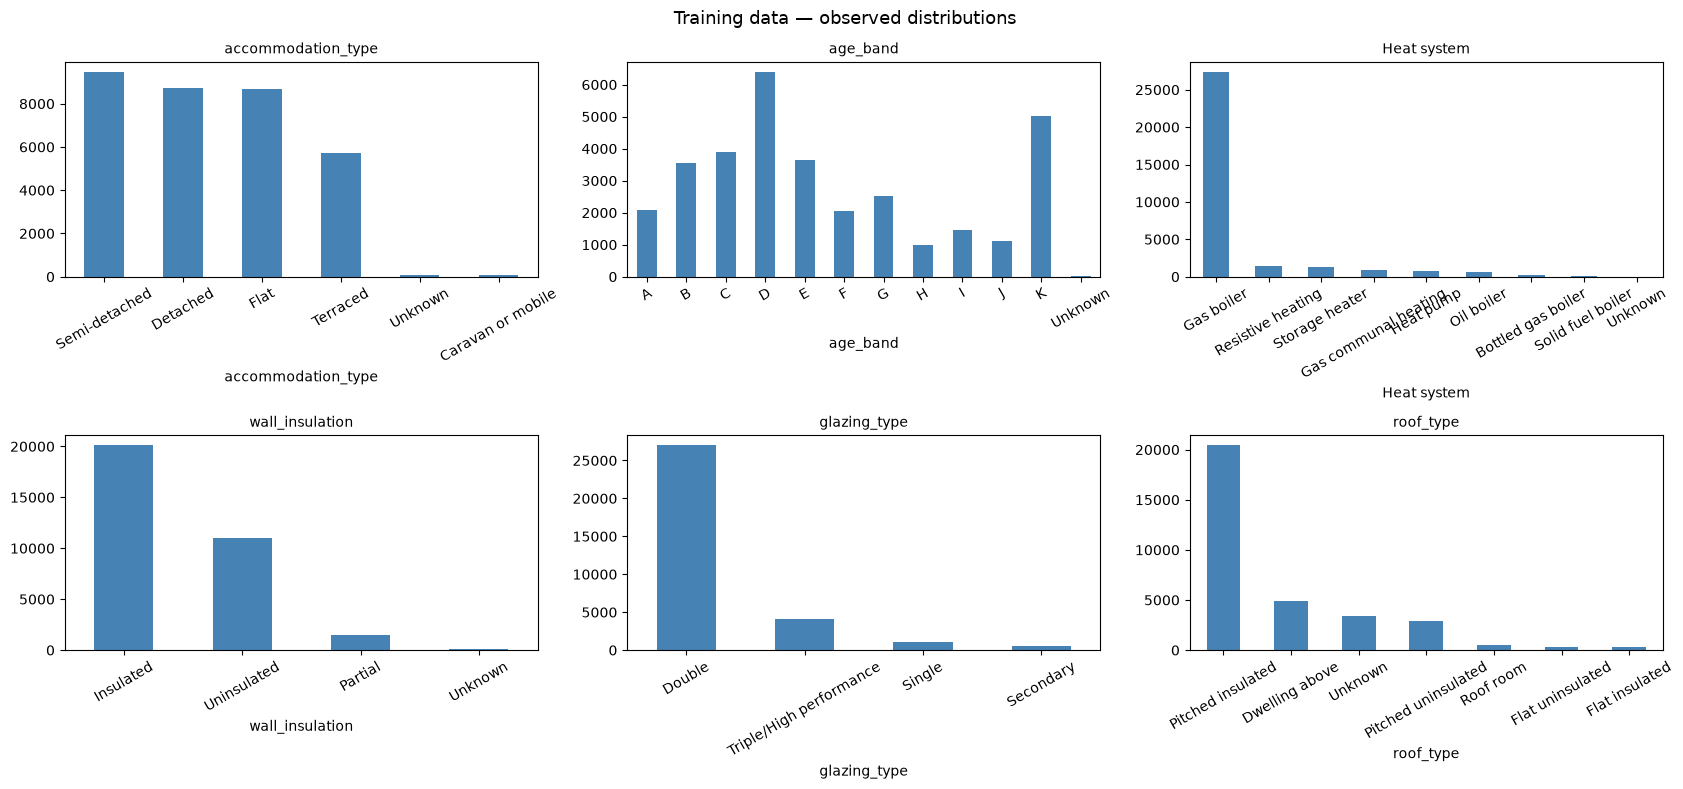

records per LSOA:
  min 185 (E01030476) | median 369 | max 981 (E01030452)


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
fig.suptitle('Training data — observed distributions', fontsize=13)
for ax, col in zip(axes.ravel(),
                   ['accommodation_type', 'age_band', 'Heat system',
                    'wall_insulation', 'glazing_type', 'roof_type']):
    vc = train[col].value_counts()
    vc = vc.sort_index() if col == 'age_band' else vc
    vc.plot.bar(ax=ax, rot=30, color='steelblue')
    ax.set_title(col, fontsize=10)
plt.tight_layout(); plt.show()

print('records per LSOA:')
lc = train.groupby('LSOA').size()
print(f'  min {lc.min()} ({lc.idxmin()}) | median {lc.median():.0f} | max {lc.max()} ({lc.idxmax()})')

## 3 · Train the generator

In [5]:
g = mostly.train(
    name='EPC Guildford — clean inputs',
    config={
        'tables': [{
            'name': 'epc',
            'data': train,
            'tabular_model_configuration': {
                'model': 'MOSTLY_AI/Small',
                'max_training_time': 10,      # minutes; None = train to convergence
            },
        }]
    },
    wait=True,
)
print('Status:', g.training_status)

Created generator ]8;id=5838203;http://127.0.0.1:8080/d/generators/f0bfc56a-45df-4959-8d22-b95ce6268907\f0bfc56a-45df-4959-8d22-b95ce6268907]8;;\

Started generator training

[Review copy: embedded interactive output or widget payload omitted; calculation code is retained.]


🎉 Your generator is ready! Use it to create synthetic data. Publish it so others can do the same.

Status: ProgressStatus.done


In [6]:
g.reports(display=True)

[Review copy: large cached report or log omitted; calculation code is retained.]


## 4 · Validate — unconditional and conditional

**Unconditional:** does a free-running sample reproduce the marginal distributions?

**Conditional:** seed the generator with the held-out test set's `LSOA` + `accommodation_type` and
check it reproduces the *other six* features. This is the property the gap synthesis depends on,
so it is the one that matters.

In [7]:
probe = mostly.probe(g, size=5_000)

print('MARGINALS — train vs free-running sample')
for col in FEATURES:
    comp = pd.concat([
        train[col].value_counts(normalize=True).rename('train'),
        probe[col].value_counts(normalize=True).rename('synth'),
    ], axis=1).fillna(0)
    comp['diff_pp'] = (comp['synth'] - comp['train']) * 100
    print(f'\n-- {col} --   max abs diff: {comp["diff_pp"].abs().max():.2f} pp')
    print(comp.round(4).to_string())

MARGINALS — train vs free-running sample

-- accommodation_type --   max abs diff: 1.83 pp
                     train   synth  diff_pp
accommodation_type                         
Semi-detached       0.2895  0.2766  -1.2856
Detached            0.2667   0.285   1.8252
Flat                0.2648  0.2638  -0.0992
Terraced            0.1746  0.1722  -0.2433
Unknown             0.0026  0.0016  -0.0967
Caravan or mobile   0.0018  0.0008  -0.1003

-- Heat system --   max abs diff: 0.63 pp
                       train   synth  diff_pp
Heat system                                  
Gas boiler            0.8369  0.8432   0.6311
Resistive heating     0.0436  0.0432  -0.0443
Storage heater        0.0405  0.0368  -0.3665
Gas communal heating  0.0285   0.025  -0.3454
Heat pump             0.0248  0.0206  -0.4186
Oil boiler            0.0173  0.0236   0.6302
Bottled gas boiler    0.0070   0.006  -0.1029
Solid fuel boiler     0.0013  0.0016   0.0255
Unknown               0.0001     0.0  -0.0092

-- wall

In [8]:
test_seed = test[SEED_COLS].copy()
synth_test = mostly.probe(g, seed=test_seed)
print(f'generated {len(synth_test):,} test-conditioned rows')

# Total variation distance per conditioned feature: 0 = identical, 1 = disjoint
print('\nCONDITIONAL FIDELITY (seeded on LSOA + accommodation_type)')
rows = []
for col in [c for c in FEATURES if c != 'accommodation_type']:
    o = test[col].value_counts(normalize=True)
    s = synth_test[col].value_counts(normalize=True)
    idx = o.index.union(s.index)
    tvd = 0.5 * (o.reindex(idx, fill_value=0) - s.reindex(idx, fill_value=0)).abs().sum()
    rows.append({'feature': col, 'TVD': tvd})
tv = pd.DataFrame(rows).sort_values('TVD', ascending=False)
print(tv.to_string(index=False))
print('\n(TVD < 0.05 is a good match; > 0.15 warrants a longer training run)')

generated 8,183 test-conditioned rows

CONDITIONAL FIDELITY (seeded on LSOA + accommodation_type)
          feature      TVD
         age_band 0.032018
           TENURE 0.029207
wall_construction 0.017720
      Heat system 0.016375
        roof_type 0.009043
     glazing_type 0.008066
  wall_insulation 0.006966

(TVD < 0.05 is a good match; > 0.15 warrants a longer training run)


In [9]:
# Per accommodation type, the detail that matters for energy modelling
for col in ['wall_insulation', 'Heat system', 'age_band']:
    o = test.groupby('accommodation_type')[col].value_counts(normalize=True).rename('observed')
    s = synth_test.groupby('accommodation_type')[col].value_counts(normalize=True).rename('synthetic')
    comp = pd.concat([o, s], axis=1).fillna(0)
    comp['diff_pp'] = (comp['synthetic'] - comp['observed']) * 100
    print(f'\n===== {col} =====')
    print(comp.round(3).to_string())


===== wall_insulation =====
                                    observed  synthetic  diff_pp
accommodation_type wall_insulation                              
Caravan or mobile  Unknown             0.615      0.538   -7.692
                   Insulated           0.385      0.308   -7.692
Detached           Insulated           0.611      0.607   -0.376
                   Uninsulated         0.354      0.362    0.892
                   Partial             0.033      0.028   -0.516
                   Unknown             0.002      0.002      0.0
Flat               Insulated           0.678      0.652   -2.681
                   Uninsulated         0.255      0.296    4.089
                   Partial             0.064      0.049   -1.454
                   Unknown             0.003      0.003    0.045
Semi-detached      Insulated           0.566       0.61    4.403
                   Uninsulated         0.420      0.375   -4.486
                   Partial             0.013      0.015    0.

## 5 · Generate the gap

In [10]:
gap_synth = mostly.probe(g, seed=gap_seed)
gap_synth['is_synthetic'] = True
gap_synth['UPRN'] = pd.NA

print(f'generated {len(gap_synth):,} synthetic dwellings')
print(f'LSOAs covered: {gap_synth["LSOA"].nunique()}')
print()
print(gap_synth['accommodation_type'].value_counts().to_string())

# The seed must be honoured exactly, or the Census reconciliation breaks.
want = gap_seed.groupby(SEED_COLS).size().sort_index()
got  = gap_synth.groupby(SEED_COLS).size().sort_index().reindex(want.index, fill_value=0)
mismatch = (want != got).sum()
print(f'\nrow count      : {len(gap_synth):,} generated vs {len(gap_seed):,} seeded')
print(f'seed cells off : {mismatch} of {len(want)}')
if mismatch:
    d = pd.DataFrame({'seeded': want, 'generated': got})
    print(d[d['seeded'] != d['generated']].head(10).to_string())
else:
    print('seed honoured exactly')

generated 16,493 synthetic dwellings
LSOAs covered: 83

accommodation_type
Detached             7907
Semi-detached        6395
Terraced             1041
Flat                  757
Caravan or mobile     393

row count      : 16,493 generated vs 16,493 seeded
seed cells off : 0 of 321
seed honoured exactly


## 6 · Assemble the completed stock

Observed rows keep their real UPRN. Synthetic rows have `UPRN = NA` — they are dwellings we know
must exist from the Census but have no certificate for. Allocating them to specific buildings is
the next stage, not this one.

In [11]:
observed_all = pd.concat([train_full, test_full], ignore_index=True)
observed_all['is_synthetic'] = False

complete = pd.concat([observed_all[TRAIN_COLS + ['UPRN', 'is_synthetic']],
                      gap_synth[TRAIN_COLS + ['UPRN', 'is_synthetic']]],
                     ignore_index=True)
complete.insert(0, 'dwelling_id', np.arange(1, len(complete) + 1))

print(f'observed  : {(~complete["is_synthetic"]).sum():,}')
print(f'synthetic : {complete["is_synthetic"].sum():,}')
print(f'TOTAL     : {len(complete):,}')
print(f'LSOAs     : {complete["LSOA"].nunique()} of 84')
print()
n_u = complete['UPRN'].notna().sum()
print(f'rows with a real UPRN : {n_u:,}')
print(f'distinct UPRNs        : {complete["UPRN"].nunique():,}  '
      f'(must equal the above — no duplication)')
assert complete.loc[complete['UPRN'].notna(), 'UPRN'].is_unique, \
    'UPRN duplicated — the observed rows were mis-joined'
assert not complete['UPRN'].dropna().str.contains('E', case=False, regex=False).any()
print('UPRN integrity: OK')

[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


In [12]:
# Reconcile the completed stock against Census
final_counts = (complete.pivot_table(index='LSOA', columns='accommodation_type',
                                     values='dwelling_id', aggfunc='count')
                .reindex(columns=census.columns, fill_value=0)
                .reindex(census.index, fill_value=0).fillna(0).astype(int))
diff = final_counts - census

print('COMPLETED STOCK vs CENSUS')
rec = pd.DataFrame({'census': census.sum(), 'completed': final_counts.sum(),
                    'diff': diff.sum()})
rec['diff_%'] = (100 * rec['diff'] / rec['census']).round(2)
print(rec.to_string())
print(f'\nTOTAL  census {census.values.sum():,}  completed {final_counts.values.sum():,}  '
      f'diff {diff.values.sum():+,}')
print('\n(the surplus is the clamped over-count from notebook 01 — vacant dwellings,')
print(' second homes and halls of residence, which are dwellings but not households)')

COMPLETED STOCK vs CENSUS
                   census  completed  diff  diff_%
Detached            18666      18765    99    0.53
Semi-detached       18177      18251    74    0.41
Terraced             7589       8192   603    7.95
Flat                10858      11622   764    7.04
Caravan or mobile     464        465     1    0.22

TOTAL  census 55,754  completed 57,295  diff +1,541

(the surplus is the clamped over-count from notebook 01 — vacant dwellings,
 second homes and halls of residence, which are dwellings but not households)


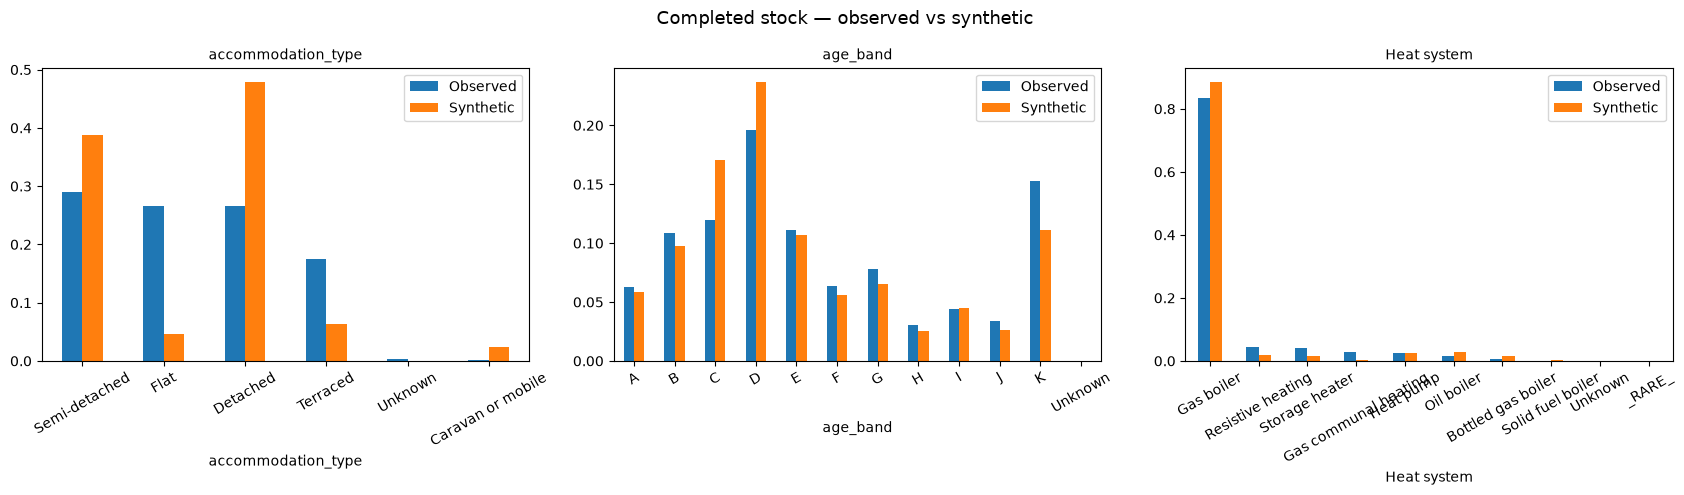

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Completed stock — observed vs synthetic', fontsize=13)
for ax, col in zip(axes, ['accommodation_type', 'age_band', 'Heat system']):
    o = complete[~complete['is_synthetic']][col].value_counts(normalize=True)
    s = complete[complete['is_synthetic']][col].value_counts(normalize=True)
    d = pd.concat([o.rename('Observed'), s.rename('Synthetic')], axis=1).fillna(0)
    if col == 'age_band':
        d = d.sort_index()
    d.plot.bar(ax=ax, rot=30)
    ax.set_title(col, fontsize=10)
plt.tight_layout(); plt.show()

## 7 · Export

In [14]:
complete.to_csv(OUT / 'guildford_stock_complete.csv', index=False)
complete.to_parquet(OUT / 'guildford_stock_complete.parquet', index=False)
g.export_to_file(OUT / 'guildford_epc_generator.zip')

print('wrote:')
for f in ['guildford_stock_complete.csv', 'guildford_stock_complete.parquet',
          'guildford_epc_generator.zip']:
    p = OUT / f
    print(f'  {p}  ({p.stat().st_size/1e6:.1f} MB)')

print('\nRead the CSV back with dtype={"UPRN": str} — without it pandas turns the')
print('UPRN into a float and you have reintroduced the corruption at the read end.')
complete.head()

[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


## Completed stock

The export combines observed dwellings with generated records for the Census gap. Generated attributes reflect the EPC training sample and may inherit its selection bias; the next notebook assigns these records to addresses.
